# This is gesture recognization sandbox notebook

In [2]:
from fileinput import filename
import urllib.request
import os

url = "https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task"

filename = "gesture_recognizer.task"

# check if the file already exists

if not os.path.exists(filename):
    print("Downloading gesture recognizer model...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print("File already exists. Skipping download.")

File already exists. Skipping download.


## visualization utilities

In [ ]:
from matplotlib import pyplot as plt
import mediapipe as mp

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'xtick.labelbottom': False,
    'xtick.bottom': False,
    'ytick.labelleft': False,
    'ytick.left': False,
    'xtick.labeltop': False,
    'xtick.top': False,
    'ytick.labelright': False,
    'ytick.right': False
})

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

def display_one_image(image,title,subplot,titlesize=16):
    """Displays one image along with the predicted category and its score."""
    plt.subplot(*subplot)
    plt.imshow(image)
    if len(title) > 0:
        plt.title(title, fontsize=int(titlesize), color='black', fontdict={'verticalalignment':'center'}, pad=int(titlesize/1.5))
    return (subplot[0],subplot[1],subplot[2]+1)


def display_batch_of_images_with_gestures_and_hand_landmarks(images,results):
    """Displays a batch of images with the gesture category and its score along with the hand landmarks drawn on the image."""
    # images and labels.
    images= [image.numpy_view() for image in images]
    gestures = [top_gesture for (top_gesture,_)in results]
    multi_hand_landmarks_list = [multi_hand_landmarks for (_,multi_hand_landmarks) in results]


    # Auto Squaring: this will drop data that does not fit inot square or square-ish grid.

    rows = int(math.sqrt(len(images)))
    cols = len(images) // rows

    # Size and spacing
    FIGSIZE = 13.0
    SPACING = 0.1
    subplot = (rows,cols,1  )

    if rows < cols:
        plt.figure(figsize=(FIGSIZE, FIGSIZE /cols * rows))
    else:
        plt.figure(figsize=(FIGSIZE / rows * cols, FIGSIZE))


    # Display gestures and hand landmarks.
    for i, (image, gestures) in enumerate(zip(images[:rows*cols], gestures[:rows*cols])):
        title = f"{gestures.category_name} ({gestures.score:.2f})"
        dynamic_titlesize = FIGSIZE*SPACING/max(rows,cols)* 40 + 3
        annotated_image = image.copy()


        for hand_landmarks in multi_hand_landmarks_list[i]:
            mp_drawing.draw_landmarks(
                annotated_image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())

        subplot = display_one_image(annotated_image, title, subplot, titlesize=dynamic_titlesize)

    #layout

    plt.tight_layout()
    plt.subplots_adjust(wspace=SPACING, hspace=SPACING)
    plt.show()





## Download test images

In [4]:
import urllib

IMAGE_FILENAMES = ['thumbs_down.jpg', 'victory.jpg', 'thumbs_up.jpg', 'pointing_up.jpg']

for name in IMAGE_FILENAMES:
  url = f'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/{name}'
  urllib.request.urlretrieve(url, name)


thumbs_down.jpg


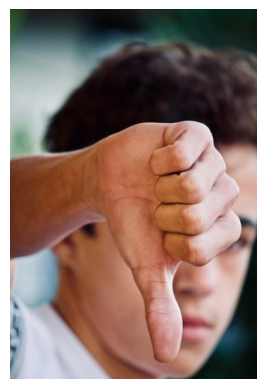

victory.jpg


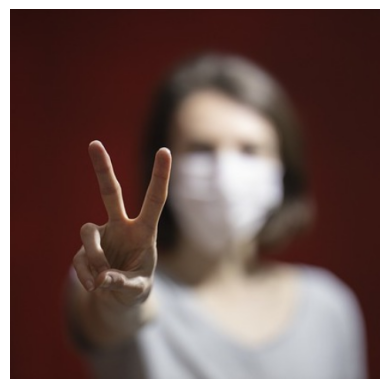

thumbs_up.jpg


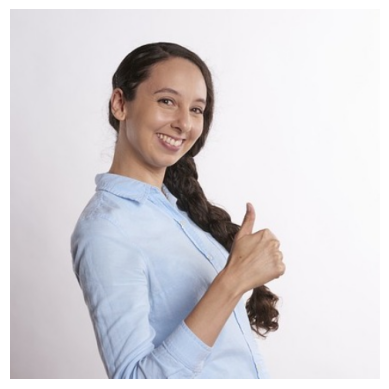

pointing_up.jpg


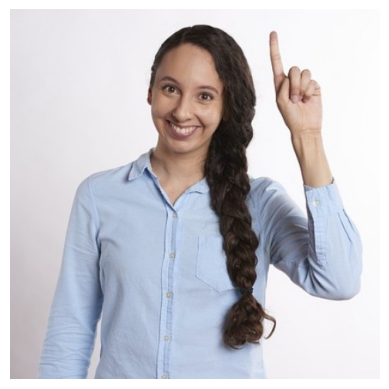

In [7]:
import math
import cv2
import matplotlib.pyplot as plt

DESIRED_HEIGHT = 480
DESIRED_WIDTH = 480


def resize_and_show(image):
    h, w = image.shape[:2]
    if h < w:
        img = cv2.resize(
            image, (DESIRED_WIDTH, math.floor(h / (w / DESIRED_WIDTH)))
        )
    else:
        img = cv2.resize(
            image, (math.floor(w / (h / DESIRED_HEIGHT)), DESIRED_HEIGHT)
        )

    # 1. Convert OpenCV BGR format to RGB format for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Display inline
    plt.figure()
    plt.imshow(img_rgb)
    plt.axis("off")  # Hides the X/Y axis pixel ticks
    plt.show()


# Preview the images
images = {name: cv2.imread(name) for name in IMAGE_FILENAMES}
for name, image in images.items():
    print(name)
    resize_and_show(image)

I0000 00:00:1785150854.832501   13223 hand_gesture_recognizer_graph.cc:250] Custom gesture classifier is not defined.
I0000 00:00:1785150854.837823   13223 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1785150854.841343   13244 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: AMD Radeon 780M Graphics (radeonsi, phoenix, LLVM 20.1.2, DRM 3.57, 6.8.0-136-generic)
W0000 00:00:1785150854.867632   13230 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785150854.884252   13237 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785150854.885216   13237 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00

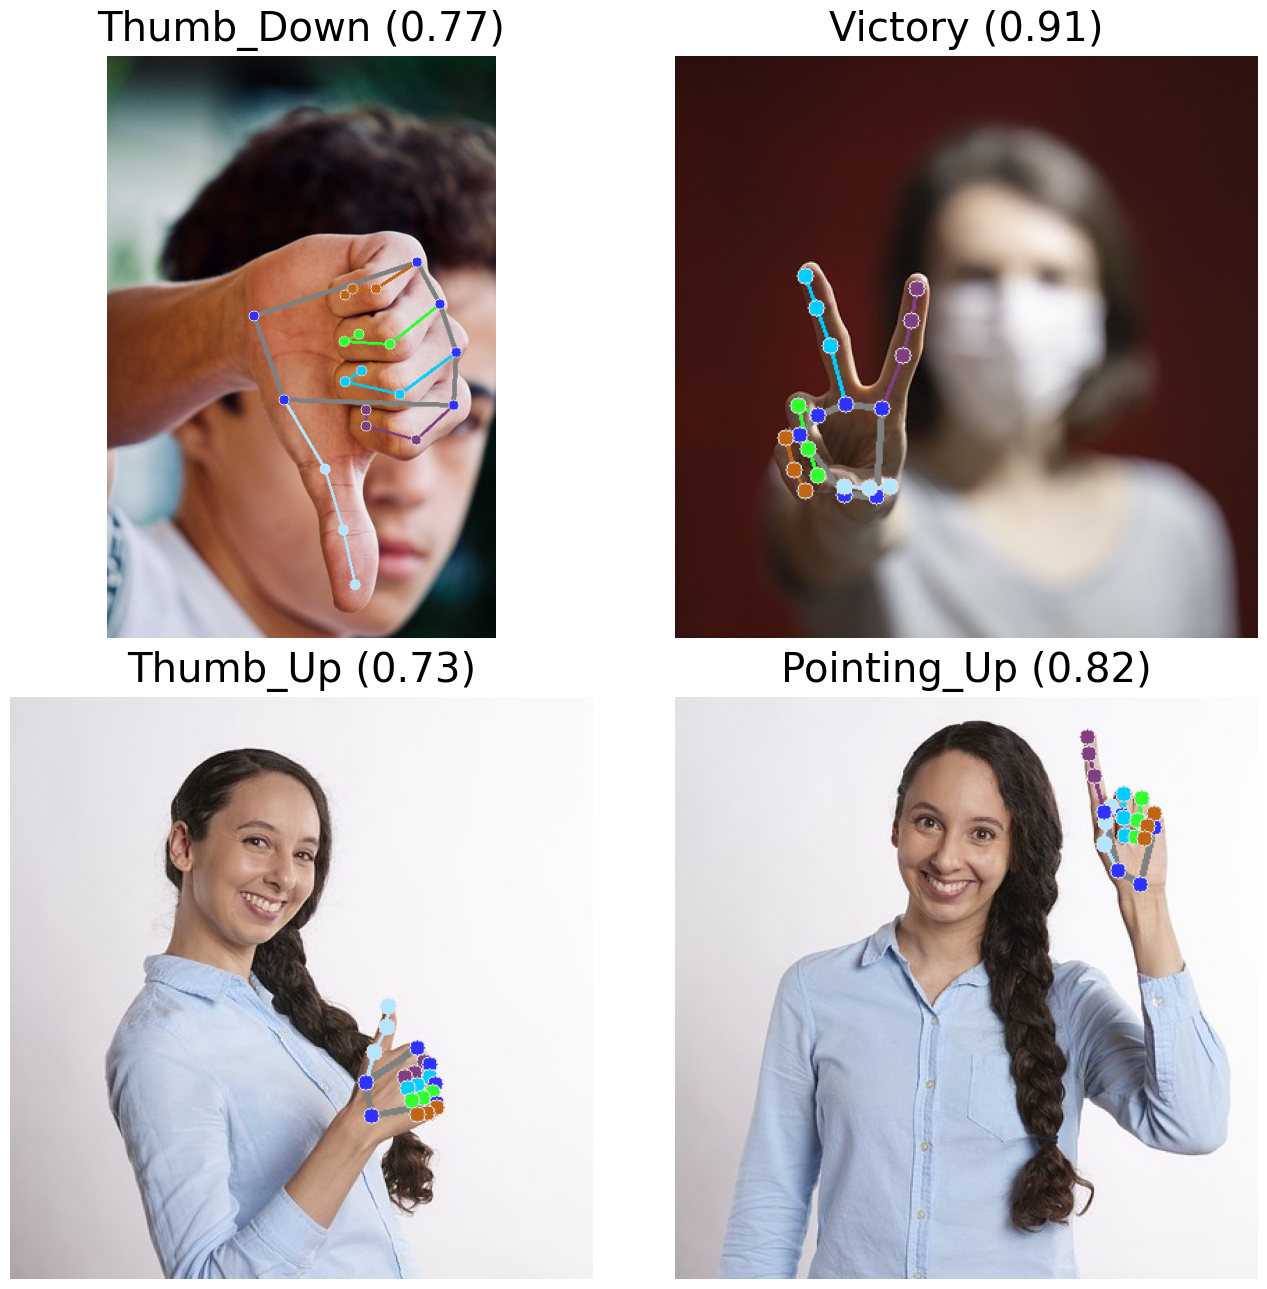

In [8]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an GestureRecognizer object.
base_options = python.BaseOptions(model_asset_path='gesture_recognizer.task')
options = vision.GestureRecognizerOptions(base_options=base_options)
recognizer = vision.GestureRecognizer.create_from_options(options)

images = []
results = []
for image_file_name in IMAGE_FILENAMES:
  # STEP 3: Load the input image.
  image = mp.Image.create_from_file(image_file_name)

  # STEP 4: Recognize gestures in the input image.
  recognition_result = recognizer.recognize(image)

  # STEP 5: Process the result. In this case, visualize it.
  images.append(image)
  top_gesture = recognition_result.gestures[0][0]
  hand_landmarks = recognition_result.hand_landmarks
  results.append((top_gesture, hand_landmarks))

display_batch_of_images_with_gestures_and_hand_landmarks(images, results)